Cloning into 'aprendizaje_profundo'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 168 (delta 86), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 548.08 KiB | 4.49 MiB/s, done.
Resolving deltas: 100% (86/86), done.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,859 (38.51 KB)

 Trainable params: 9,859 (38.51 KB)

 Non-trainable params: 0 (0.00 B)


Entrenamiento finalizado en la época: 70


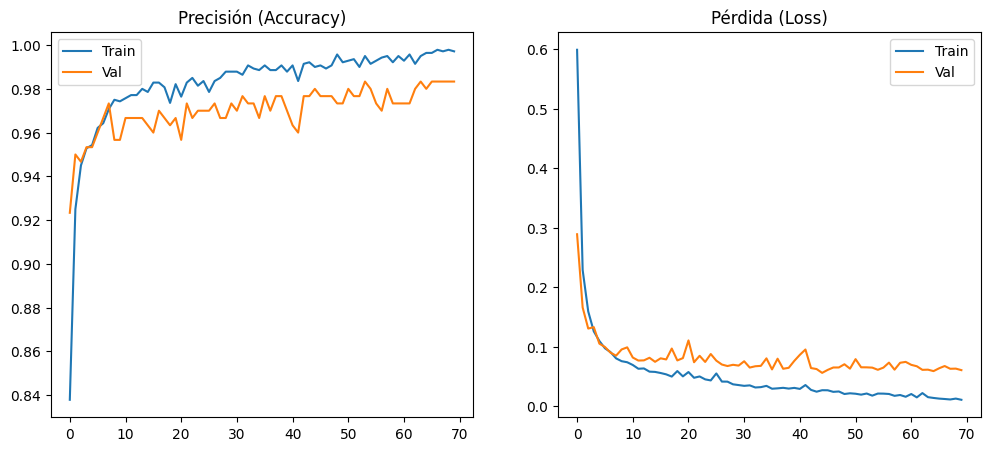

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Total Params:     9859
Train Accuracy:   0.9957
Val Accuracy:     0.9800
Test Accuracy:    0.9767
F1 Macro (Test):  0.9397


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

if os.path.exists('aprendizaje_profundo'):
    shutil.rmtree('aprendizaje_profundo')

!git clone https://github.com/macaspe4/aprendizaje_profundo.git


from modelos.modelo_complejos4 import crear_modelo

df = pd.read_csv('wfh_burnout_dataset.csv')
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

model = crear_modelo(X_train_sc.shape[1])
model.summary()

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(X_train_sc, y_train,
                    validation_data=(X_val_sc, y_val),
                    epochs=300,
                    callbacks=[callback],
                    verbose=0)

print(f"\nEntrenamiento finalizado en la época: {len(history.history['loss'])}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida (Loss)')
plt.legend()
plt.show()

y_train_pred = np.argmax(model.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(model.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(model.predict(X_test_sc), axis=1)


print(f"Total Params:     {model.count_params()}")
print(f"Train Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy:     {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Macro (Test):  {f1_score(y_test, y_test_pred, average='macro'):.4f}")


### Conclusión
Este cuarto modelo usa una arquitectura ancha pero poco profunda, con 128 y 64 neuronas en las capas ocultas, lo que aumenta bastante su tamaño hasta 9.859 parámetros. Gracias a esta gran capacidad, el modelo aprende muy rápido y el entrenamiento se detiene en la época 70 usando Early Stopping.

Los resultados también son muy buenos: 99,57% de precisión en entrenamiento y 97,67% en test. Sin embargo, no mejora de forma clara los resultados obtenidos con modelos mucho más pequeños que analizamos antes.

Esto indica que el problema de predecir el riesgo de burnout puede resolverse bien sin usar redes tan grandes. Aunque estos modelos grandes aprenden rápido, también pueden tener más riesgo de memorizar los datos si no se controlan bien.